In [1]:
import polars as pl
import numpy as np
from sklearn.metrics import mean_absolute_error

model_df = pl.read_parquet("../../data/clean/model_ready.parquet")
print(model_df.shape)
print(model_df.columns)

(371604, 12)
['DEST', 'date', 'arr_hour', 'arr_15min_block', 'arrivals', 'day_of_week', 'month', 'year', 'is_weekend', 'COVID_FLAG', 'hist_mean_arrivals', 'scheduled_arrivals']


In [2]:
train = model_df.filter(pl.col("year").is_in([2019, 2022]))
test = model_df.filter(pl.col("year") == 2023)

print("train:", train.shape)
print("test:", test.shape)

train: (278943, 12)
test: (92661, 12)


In [3]:
feature_cols = [
    "arr_hour",
    "arr_15min_block",
    "day_of_week",
    "month",
    "is_weekend",
    "scheduled_arrivals",
    "hist_mean_arrivals"
]

X_train = train.select(feature_cols).to_numpy()
y_train = train.select("arrivals").to_numpy().ravel()

X_test = test.select(feature_cols).to_numpy()
y_test = test.select("arrivals").to_numpy().ravel()

In [4]:
baseline_preds = test.select("hist_mean_arrivals").to_numpy().ravel()
baseline_mae = mean_absolute_error(y_test, baseline_preds)
print(f"baseline MAE: {baseline_mae:.4f} arrivals per 15-min slot")

baseline MAE: 0.6668 arrivals per 15-min slot


In [5]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

xgb_preds = model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_preds)

print(f"baseline MAE: {baseline_mae:.4f}")
print(f"XGBoost MAE: {xgb_mae:.4f}")
print(f"improvement: {((baseline_mae - xgb_mae) / baseline_mae * 100):.1f}%")

baseline MAE: 0.6668
XGBoost MAE: 0.0000
improvement: 100.0%


In [6]:
# compute mean from training set only
hist_mean_train = train.group_by(["DEST", "arr_hour", "day_of_week"]).agg(
    pl.col("arrivals").mean().alias("hist_mean_arrivals_fixed")
)

# join onto test set
test_fixed = test.join(
    hist_mean_train,
    on=["DEST", "arr_hour", "day_of_week"],
    how="left"
).with_columns(
    pl.col("hist_mean_arrivals_fixed").fill_null(
        pl.col("hist_mean_arrivals")
    )
)

# also remove scheduled_arrivals from features - it's too close to target
feature_cols_fixed = [
    "arr_hour",
    "arr_15min_block",
    "day_of_week",
    "month",
    "is_weekend",
    "hist_mean_arrivals_fixed"
]

X_train_fixed = train.join(
    hist_mean_train,
    on=["DEST", "arr_hour", "day_of_week"],
    how="left"
).select(feature_cols_fixed).to_numpy()

X_test_fixed = test_fixed.select(feature_cols_fixed).to_numpy()
y_test_fixed = test_fixed.select("arrivals").to_numpy().ravel()

In [7]:
model_fixed = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

model_fixed.fit(X_train_fixed, y_train)
xgb_preds_fixed = model_fixed.predict(X_test_fixed)
xgb_mae_fixed = mean_absolute_error(y_test_fixed, xgb_preds_fixed)

baseline_fixed = test_fixed.select("hist_mean_arrivals_fixed").to_numpy().ravel()
baseline_mae_fixed = mean_absolute_error(y_test_fixed, baseline_fixed)

print(f"baseline MAE: {baseline_mae_fixed:.4f}")
print(f"XGBoost MAE: {xgb_mae_fixed:.4f}")
print(f"improvement: {((baseline_mae_fixed - xgb_mae_fixed) / baseline_mae_fixed * 100):.1f}%")

baseline MAE: 0.6760
XGBoost MAE: 0.6589
improvement: 2.5%


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_dest = le.fit_transform(train["DEST"].to_numpy())
test_dest = le.transform(test_fixed["DEST"].to_numpy())

X_train_v2 = np.column_stack([X_train_fixed, train_dest])
X_test_v2 = np.column_stack([X_test_fixed, test_dest])

model_v2 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

model_v2.fit(X_train_v2, y_train)
preds_v2 = model_v2.predict(X_test_v2)
mae_v2 = mean_absolute_error(y_test_fixed, preds_v2)

print(f"baseline MAE:   {baseline_mae_fixed:.4f}")
print(f"XGBoost v1 MAE: {xgb_mae_fixed:.4f} — no airport encoding")
print(f"XGBoost v2 MAE: {mae_v2:.4f} — with airport encoding")
print(f"improvement over baseline: {((baseline_mae_fixed - mae_v2) / baseline_mae_fixed * 100):.1f}%")

baseline MAE:   0.6760
XGBoost v1 MAE: 0.6589 — no airport encoding
XGBoost v2 MAE: 0.6555 — with airport encoding
improvement over baseline: 3.0%


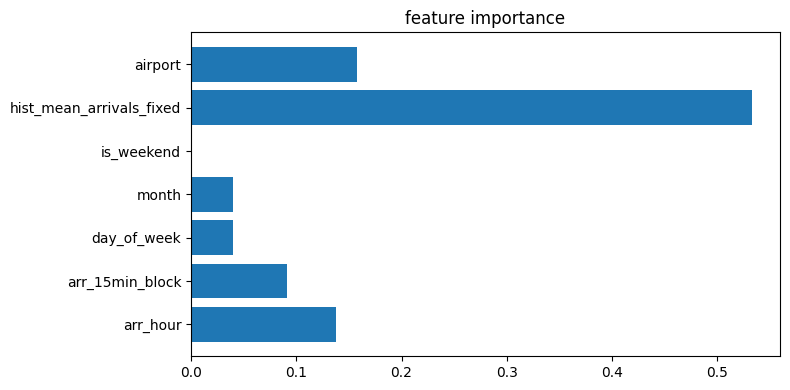

In [9]:
import matplotlib.pyplot as plt

feature_names = feature_cols_fixed + ["airport"]
importances = model_v2.feature_importances_

plt.figure(figsize=(8, 4))
plt.barh(feature_names, importances)
plt.title("feature importance")
plt.tight_layout()
plt.show()

In [10]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# train three models - low, median, high
quantiles = {
    "q10": 0.1,
    "q50": 0.5,
    "q90": 0.9
}

q_models = {}
q_preds = {}

for name, q in quantiles.items():
    m = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        objective="reg:quantileerror",
        quantile_alpha=q,
        random_state=42,
        n_jobs=-1
    )
    m.fit(X_train_v2, y_train)
    q_models[name] = m
    q_preds[name] = m.predict(X_test_v2)
    print(f"{name} MAE: {mean_absolute_error(y_test_fixed, q_preds[name]):.4f}")

q10 MAE: 0.6140
q50 MAE: 0.5623
q90 MAE: 1.2543


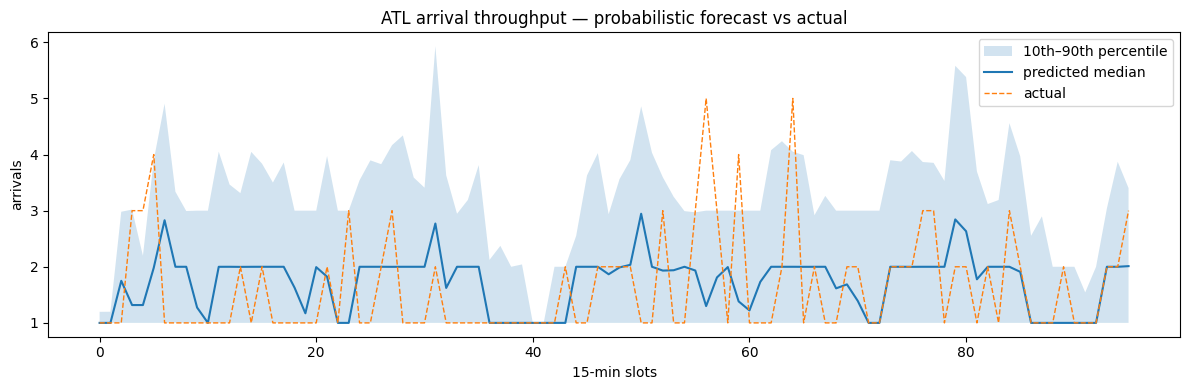

In [11]:
import matplotlib.pyplot as plt

# filter to ATL only for visualization
atl_mask = test_fixed["DEST"].to_numpy() == "ATL"
atl_actual = y_test_fixed[atl_mask][:96]  # first 96 slots = one day
atl_q10 = q_preds["q10"][atl_mask][:96]
atl_q50 = q_preds["q50"][atl_mask][:96]
atl_q90 = q_preds["q90"][atl_mask][:96]

plt.figure(figsize=(12, 4))
plt.fill_between(range(96), atl_q10, atl_q90, alpha=0.2, label="10th–90th percentile")
plt.plot(atl_q50, label="predicted median", linewidth=1.5)
plt.plot(atl_actual, label="actual", linewidth=1, linestyle="--")
plt.title("ATL arrival throughput — probabilistic forecast vs actual")
plt.xlabel("15-min slots")
plt.ylabel("arrivals")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
import os
import pickle

os.makedirs("../../models", exist_ok=True)

for name, m in q_models.items():
    with open(f"../../models/xgb_{name}.pkl", "wb") as f:
        pickle.dump(m, f)

# save label encoder too
with open("../../models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("models saved")

models saved


In [13]:
%pip install pyarrow
import importlib
importlib.invalidate_caches()
print('Installing pyarrow; restart kernel if needed')

Note: you may need to restart the kernel to use updated packages.
Installing pyarrow; restart kernel if needed



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd

# build a results dataframe
results = test_fixed.select(["DEST", "date", "arr_hour", 
                              "arr_15min_block", "arrivals",
                              "scheduled_arrivals"]).to_pandas()

results["pred_q10"] = q_preds["q10"]
results["pred_q50"] = q_preds["q50"]
results["pred_q90"] = q_preds["q90"]

# imbalance score = scheduled / predicted capacity, capped at 100
results["imbalance_score"] = (
    (results["scheduled_arrivals"] / results["pred_q50"].clip(lower=0.5)) * 20
).clip(upper=100).round(1)

print(results.groupby("DEST")["imbalance_score"].describe())

        count       mean        std   min     25%   50%   75%    max
DEST                                                                
ATL   12334.0  22.026480  12.640320   6.6  10.800  20.0  29.9  100.0
CLT    7649.0  23.820251  13.032427   9.9  17.700  20.0  30.0  100.0
DEN   10630.0  26.049370  14.329793   8.5  20.000  20.0  35.7  100.0
DFW    9722.0  24.356285  13.526332   6.3  18.925  20.0  30.0  100.0
LAS    8972.0  27.648239  13.025180  20.0  20.000  20.0  40.0  100.0
LAX    9223.0  28.274911  13.806017  11.9  20.000  20.0  40.0  100.0
LGA    7902.0  27.636042  12.896251  20.0  20.000  20.0  40.0  100.0
ORD   10016.0  22.554014  12.634040   9.9  11.400  20.0  30.0  100.0
PHX    8227.0  27.461626  13.460456  10.0  20.000  20.0  40.0  100.0
SEA    7986.0  26.802868  12.905958  10.0  20.000  20.0  40.0  100.0


In [16]:
# instead of fixed multiplier, normalize per airport
# score = scheduled / predicted, expressed as % of that airport's peak capacity

airport_peak = results.groupby("DEST")["pred_q90"].quantile(0.95).rename("peak_capacity")
results = results.join(airport_peak, on="DEST")

results["imbalance_score"] = (
    (results["scheduled_arrivals"] / results["peak_capacity"]) * 100
).clip(upper=100).round(1)

print(results.groupby("DEST")["imbalance_score"].describe())

        count       mean        std   min   25%   50%   75%    max
DEST                                                              
ATL   12334.0  37.949732  21.114432  21.0  21.0  21.0  42.0  100.0
CLT    7649.0  41.301360  22.390226  24.8  24.8  24.8  49.7  100.0
DEN   10630.0  37.346623  22.093641  21.0  21.0  21.0  42.1  100.0
DFW    9722.0  35.789560  22.761002  18.9  18.9  18.9  37.7  100.0
LAS    8972.0  49.941819  20.508027  37.0  37.0  37.0  74.0  100.0
LAX    9223.0  46.803155  21.242949  33.3  33.3  33.3  66.7  100.0
LGA    7902.0  46.799089  20.186190  34.3  34.3  34.3  68.5  100.0
ORD   10016.0  40.915375  22.792551  24.2  24.2  24.2  48.3  100.0
PHX    8227.0  46.153847  20.812402  33.3  33.3  33.3  66.7  100.0
SEA    7986.0  44.982820  20.098663  33.3  33.3  33.3  66.7  100.0


In [18]:
results.to_parquet("../../data/clean/imbalance_scores.parquet")
print("saved")
print(results.columns.tolist())

saved
['DEST', 'date', 'arr_hour', 'arr_15min_block', 'arrivals', 'scheduled_arrivals', 'pred_q10', 'pred_q50', 'pred_q90', 'imbalance_score', 'peak_capacity']


In [19]:
sample = results[results["date"] == results["date"].max()][
    ["DEST", "imbalance_score"]
].groupby("DEST")["imbalance_score"].mean().round(1).reset_index()

print(sample)

  DEST  imbalance_score
0  ATL             34.5
1  CLT             42.3
2  DEN             41.3
3  DFW             36.6
4  LAS             46.8
5  LAX             57.0
6  LGA             46.8
7  ORD             42.9
8  PHX             40.9
9  SEA             43.0
